# Social XR Motion Analysis: Temporal Synchrony, Social Synchrony, Hand Synchrony, Proxemics

A **format-agnostic** version of the dyadic head-motion analysis: point it at
any social-XR session -- regardless of which export format it came from --
and it runs the same synchrony/proxemics pipeline over however many
participants that session has (2, 3, 7, ...).

**Supported formats** (see `../lib/xr_loaders.py` for the full spec of each):

| format | example | layout | rotation | hands | voice |
|---|---|---|---|---|---|
| `position_rotation_csv` | `8-1_position_rotation.csv` + `8-2_position_rotation.csv` | one file per participant | Euler | yes | no |
| `quest_csv` | `Experiment1_30Hz_Quest.csv` | one file, whole session | quaternion | no | no |
| `pkl_long` | `H01_H02_fashion_xzy.pkl`, `conflab_ep02_4_33_42.pkl` | one file, whole session | (position + facing vector only) | no | yes (conflab) |

Every format is normalized on load into one **unified long-format schema**
(`participant_id`, `t_s`, `position_x/y/z`, `rotation_x/y/z`, hand
position/rotation, voice-activity flags -- NaN wherever a format doesn't
carry that signal). All analyses below run against that unified schema, so
they never need to know which format a session came from.

**This notebook:**
1. Loads a chosen session via `xr_loaders.load_session(...)`.
2. Resamples every participant onto a shared uniform time grid (solves
   cross-participant time alignment for free).
3. Runs four analyses, generalized to **all pairs** of participants:
   - **Temporal synchrony** -- windowed Pearson correlation of frame-to-frame
     3D head-speed between each pair, normalized to [0, 1].
   - **Social synchrony** -- windowed Pearson correlation of horizontal-plane
     (x, z) movement amplitude between each pair.
   - **Hand-movement synchrony** -- same pattern as temporal synchrony, but
     on combined left/right hand motion. Automatically skipped for
     participants/formats without hand tracking.
   - **Proxemics** -- pairwise 3D distance between every pair over time, with
     Hall's proxemic zone breakdown (intimate / personal / social / public).
4. Runs the whole pipeline across **all four example datasets** in one pass
   and prints a comparison table, to demonstrate that the same code path
   handles every format.

To add your own dataset: drop the file(s) in `../Data/`, add an entry to
`DATASETS` in the config cell below (or call `load_session` directly with
the right `paths=`), and re-run.

## 1. Imports & configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path('../lib').resolve()))
from xr_loaders import load_session, UNIFIED_COLUMNS
from xr_analysis import (
    resample_session, estimate_native_hz, has_hand_data,
    temporal_synchrony, social_synchrony, hand_synchrony,
    compute_proxemics, zone_breakdown, pair_summary_matrix, all_pairs,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

DATA_DIR = Path('../Data')
SYNC_WINDOW_S = 1.0       # window length for temporal / social / hand synchrony
PROXEMICS_HZ = 1.0        # proxemics doesn't need tracking-rate precision

PURPLE, ORANGE, BLUE, RED = '#7b6bd6', '#e08a3c', '#3b6fb6', '#c0392b'

# Registry of example sessions. `paths` is a single file for self-contained
# formats, or a list of one-file-per-participant files for position_rotation_csv.
DATASETS = {
    'dyad_position_rotation': dict(
        paths=[DATA_DIR / '8-1_position_rotation.csv', DATA_DIR / '8-2_position_rotation.csv']),
    'quest_7person':          dict(paths=DATA_DIR / 'quest_csv' / 'Experiment1_30Hz_Quest.csv'),
    'fashion_pkl':            dict(paths=DATA_DIR / 'pkl' / 'H01_H02_fashion_xzy.pkl'),
    'conflab_pkl':            dict(paths=DATA_DIR / 'pkl' / 'conflab_ep02_4_33_42.pkl'),
}

# <<< Choose which dataset to run through the detailed, plotted pipeline below.
SELECTED = 'dyad_position_rotation'

## 2. Load the selected session

`load_session` auto-detects the format from the file(s) and returns the
unified schema -- same columns regardless of source.

In [2]:
df = load_session(**DATASETS[SELECTED], session_id=SELECTED)
participants = sorted(df['participant_id'].unique())
native_hz = estimate_native_hz(df)

print(f"Dataset: {SELECTED}  |  format: {df['source_format'].iloc[0]}")
print(f"Participants ({len(participants)}): {participants}")
print(f"Rows: {len(df)}  |  estimated native rate: {native_hz:.1f} Hz")
print(f"Duration: {(df['t_s'].max() - df['t_s'].min()):.1f} s")
df.head()

Dataset: dyad_position_rotation  |  format: position_rotation_csv
Participants (2): ['1', '2']
Rows: 57307  |  estimated native rate: 29.0 Hz
Duration: 1003.8 s


,session_id,source_format,participant_id,t_s,position_x,position_y,position_z,rotation_x,rotation_y,rotation_z,left_hand_position_x,left_hand_position_y,left_hand_position_z,right_hand_position_x,right_hand_position_y,right_hand_position_z,left_hand_rotation_x,left_hand_rotation_y,left_hand_rotation_z,right_hand_rotation_x,right_hand_rotation_y,right_hand_rotation_z,is_speaking,is_muted
0,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360913,-2.414660,0.988270,358.5654,84.09101,215.6122,-5.222950,-2.193258,0.330182,NaN,NaN,NaN,357.2315,265.3522,149.1852,NaN,NaN,NaN,NaN,NaN
1,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360918,-2.414667,0.988270,358.5660,84.09113,215.6089,-5.222950,-2.193258,0.330182,-5.521457,-2.602808,0.337104,357.2315,265.3522,149.1852,359.4841,76.37319,284.4571,NaN,NaN
2,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360923,-2.414672,0.988271,358.5677,84.09110,215.6115,-5.222958,-2.193269,0.330193,-5.521466,-2.602815,0.337092,357.2316,265.3522,149.1819,359.4841,76.37308,284.4536,NaN,NaN
3,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360923,-2.414673,0.988270,358.5679,84.09112,215.6119,-5.222944,-2.193279,0.330198,-5.521479,-2.602810,0.337089,357.2316,265.3522,149.1850,359.4841,76.37312,284.4568,NaN,NaN
4,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360909,-2.414673,0.988267,358.5640,84.09491,215.6145,-5.222931,-2.193292,0.330195,-5.521479,-2.602810,0.337089,357.2316,265.3523,149.1878,359.4841,76.37312,284.4568,NaN,NaN


## 3. Resample onto a shared time grid

Every participant's position (and hand position, where tracked) is linearly
interpolated onto one shared uniform grid spanning the overlap of all
participants' tracked time. This is generalized to any number of
participants -- a 7-person Quest session and a 2-person dyad go through the
identical resampling call.

Two grids: the session's native rate (rounded) for motion-based synchrony,
and a fixed 1 Hz grid for proxemics (distance doesn't need tracking-rate
precision, and 1 Hz keeps zone-percentage counting simple).

In [3]:
ANALYSIS_HZ = round(native_hz)
resampled = resample_session(df, rate_hz=ANALYSIS_HZ)
resampled_1hz = resample_session(df, rate_hz=PROXEMICS_HZ)

hand_tracked = [p for p in participants if has_hand_data(resampled[p])]
print(f"Analysis grid: {ANALYSIS_HZ} Hz, {len(resampled[participants[0]])} rows/participant")
print(f"Proxemics grid: {PROXEMICS_HZ} Hz, {len(resampled_1hz[participants[0]])} rows/participant")
print(f"Participants with hand tracking: {hand_tracked or 'none'}")
resampled[participants[0]].head()

Analysis grid: 29 Hz, 29109 rows/participant
Proxemics grid: 1.0 Hz, 1004 rows/participant
Participants with hand tracking: ['1', '2']


,t_s,position_x,position_y,position_z,left_hand_position_x,left_hand_position_y,left_hand_position_z,right_hand_position_x,right_hand_position_y,right_hand_position_z,session_time_s
0,1.782307e+09,-5.360914,-2.414662,0.988270,-5.222950,-2.193258,0.330182,-5.521457,-2.602808,0.337104,0.000000
1,1.782307e+09,-5.360919,-2.414668,0.988270,-5.222952,-2.193261,0.330185,-5.521459,-2.602810,0.337101,0.034483
2,1.782307e+09,-5.360923,-2.414672,0.988270,-5.222954,-2.193272,0.330195,-5.521469,-2.602814,0.337091,0.068965
3,1.782307e+09,-5.360920,-2.414673,0.988269,-5.222941,-2.193282,0.330197,-5.521479,-2.602810,0.337089,0.103448
4,1.782307e+09,-5.360910,-2.414675,0.988267,-5.222938,-2.193284,0.330193,-5.521481,-2.602808,0.337090,0.137931


## 4. Temporal synchrony

Windowed (1s) Pearson correlation of frame-to-frame 3D head-speed between
every pair of participants, normalized `(r+1)/2` onto [0, 1]. For a dyad
this is a single pair; for the 7-person Quest session it's all 21 pairs.

In [4]:
temporal_sync = temporal_synchrony(resampled, fps=ANALYSIS_HZ, window_s=SYNC_WINDOW_S)
temporal_matrix = pair_summary_matrix(temporal_sync, 'synchrony', participants)

print(f"Pairs: {len(all_pairs(participants))}  |  windows/pair: "
      f"{len(temporal_sync) // max(len(all_pairs(participants)), 1)}")
print(f"Mean synchrony across all pairs: {temporal_sync['synchrony'].mean():.4f}  "
      f"(0.5 = chance)")
temporal_matrix.round(3)

Pairs: 1  |  windows/pair: 1003
Mean synchrony across all pairs: 0.5230  (0.5 = chance)


,1,2
1,NaN,0.523
2,0.523,NaN


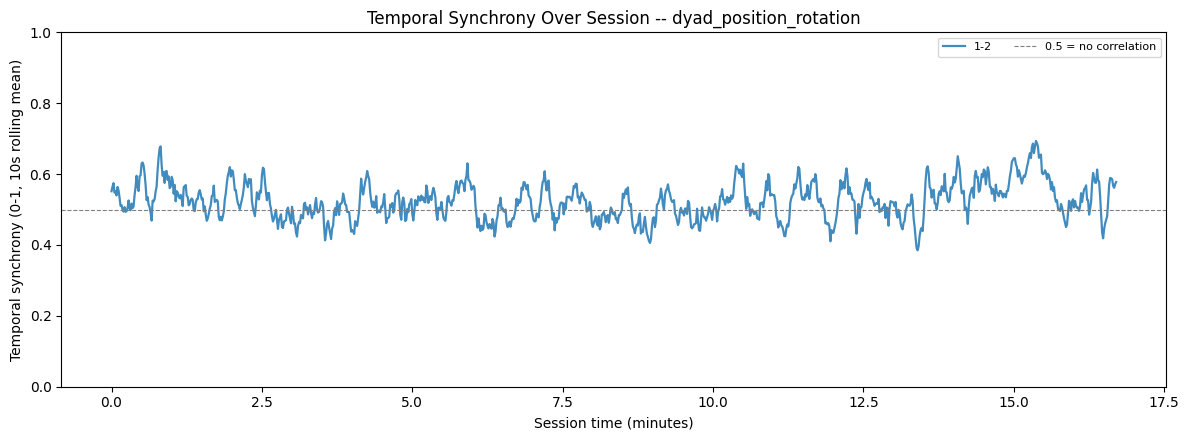

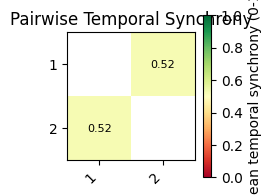

In [5]:
# --- Plot: temporal synchrony over the session (one line per pair) ---
fig, ax = plt.subplots(figsize=(12, 4.5))
cmap = plt.get_cmap('tab10')
for i, (pa, pb) in enumerate(all_pairs(participants)):
    sub = temporal_sync[(temporal_sync.participant_a == pa) & (temporal_sync.participant_b == pb)]
    minutes = sub['session_time_s'] / 60.0
    roll = sub['synchrony'].rolling(10, center=True, min_periods=1).mean()
    ax.plot(minutes, roll, linewidth=1.6, color=cmap(i % 10), alpha=0.85,
            label=f'{pa}-{pb}')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='0.5 = no correlation')
ax.set_xlabel('Session time (minutes)')
ax.set_ylabel('Temporal synchrony (0-1, 10s rolling mean)')
ax.set_title(f'Temporal Synchrony Over Session -- {SELECTED}')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(f'temporal_synchrony_{SELECTED}.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot: pairwise summary heatmap (all-pairs matrix; trivial for a dyad) ---
fig, ax = plt.subplots(figsize=(1.2 + 0.6 * len(participants), 1.0 + 0.6 * len(participants)))
im = ax.imshow(temporal_matrix.to_numpy(), cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(participants))); ax.set_xticklabels(participants, rotation=45, ha='right')
ax.set_yticks(range(len(participants))); ax.set_yticklabels(participants)
for i in range(len(participants)):
    for j in range(len(participants)):
        v = temporal_matrix.to_numpy()[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Mean temporal synchrony (0-1)')
ax.set_title('Pairwise Temporal Synchrony')
plt.tight_layout()
plt.savefig(f'temporal_synchrony_matrix_{SELECTED}.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Social synchrony

Windowed Pearson r of **horizontal-plane** (x, z) movement amplitude between
each pair -- differs from temporal synchrony in using only floor-plane
motion, and returns a *distribution* of per-window scores per pair rather
than a continuous time series.

In [6]:
social_sync = social_synchrony(resampled, fps=ANALYSIS_HZ, window_s=SYNC_WINDOW_S)
print(f"Social-synchrony windows: {len(social_sync)} across {social_sync[['participant_a','participant_b']].drop_duplicates().shape[0]} pairs")
social_sync.groupby(['participant_a', 'participant_b'])['pearson_r'].agg(['mean', 'median', 'std', 'count']).round(3)

Social-synchrony windows: 1001 across 1 pairs


,,mean,median,std,count
participant_a,participant_b,,,,
1,2,0.042,0.025,0.314,1001


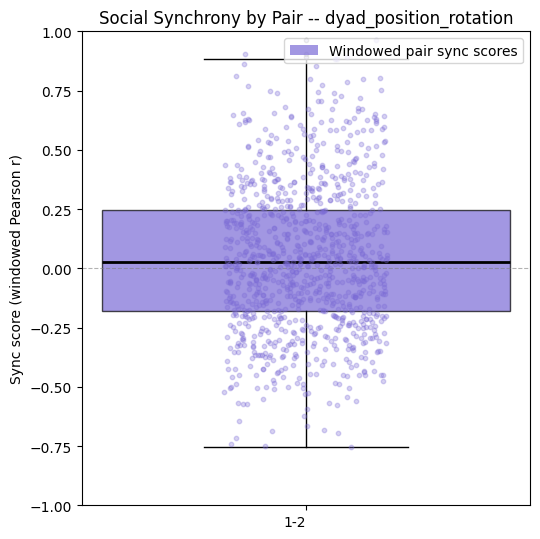

In [7]:
# --- Plot: social synchrony distribution, one box per pair ---
pair_labels = [f'{pa}-{pb}' for pa, pb in all_pairs(participants)]
data = [social_sync.loc[(social_sync.participant_a == pa) & (social_sync.participant_b == pb), 'pearson_r'].to_numpy()
        for pa, pb in all_pairs(participants)]

fig, ax = plt.subplots(figsize=(max(5.5, 1.1 * len(data)), 5.5))
bp = ax.boxplot(data, positions=range(len(data)), widths=0.4, patch_artist=True,
                 manage_ticks=False,
                 boxprops=dict(facecolor=PURPLE, alpha=0.7),
                 medianprops=dict(color='black', lw=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor=PURPLE))
for i, scores in enumerate(data):
    jitter = np.random.uniform(-0.08, 0.08, size=len(scores))
    ax.scatter(i + jitter, scores, color=PURPLE, alpha=0.3, s=10, zorder=3)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xticks(range(len(data))); ax.set_xticklabels(pair_labels, rotation=45 if len(data) > 3 else 0, ha='right')
ax.set_ylabel('Sync score (windowed Pearson r)')
ax.set_ylim(-1, 1)
ax.set_title(f'Social Synchrony by Pair -- {SELECTED}')
ax.legend(handles=[mpatches.Patch(facecolor=PURPLE, alpha=0.7, label='Windowed pair sync scores')], loc='upper right')
plt.tight_layout()
plt.savefig(f'social_synchrony_{SELECTED}.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hand-movement synchrony

Same windowed-correlation pattern as temporal synchrony, but on combined
left/right hand motion instead of head motion. Only meaningful for formats
that carry hand tracking (`position_rotation_csv` in the examples here) --
for everyone else this section reports that no hand data was available and
moves on, rather than erroring.

Hand-tracked participants: ['1', '2']
Mean hand synchrony: 0.5133  (0.5 = chance)


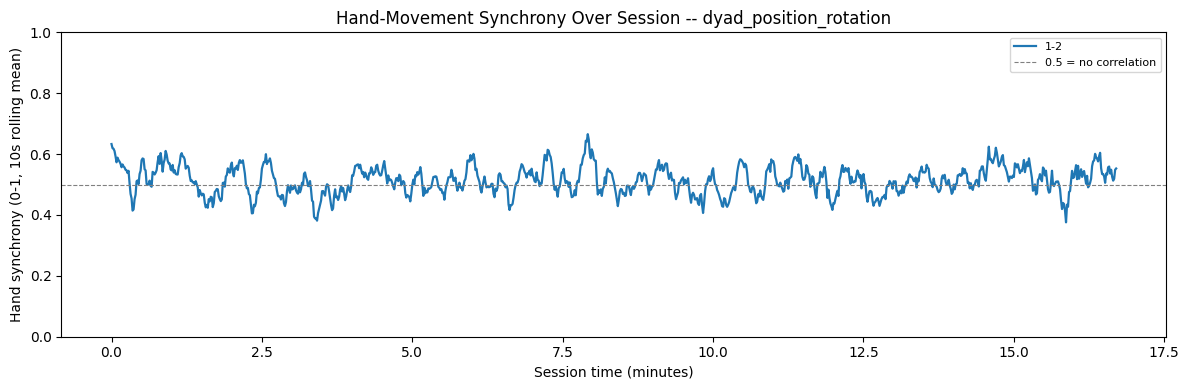

In [8]:
if len(hand_tracked) < 2:
    print(f"Hand-movement synchrony: skipped -- fewer than 2 participants with hand "
          f"tracking in this session/format ({hand_tracked or 'none tracked'}).")
    hand_sync = pd.DataFrame(columns=['participant_a', 'participant_b', 'session_time_s', 'pearson_r', 'synchrony'])
else:
    hand_sync = hand_synchrony(resampled, fps=ANALYSIS_HZ, window_s=SYNC_WINDOW_S)
    print(f"Hand-tracked participants: {hand_tracked}")
    print(f"Mean hand synchrony: {hand_sync['synchrony'].mean():.4f}  (0.5 = chance)")

    fig, ax = plt.subplots(figsize=(12, 4.0))
    for i, (pa, pb) in enumerate(all_pairs(hand_tracked)):
        sub = hand_sync[(hand_sync.participant_a == pa) & (hand_sync.participant_b == pb)]
        minutes = sub['session_time_s'] / 60.0
        roll = sub['synchrony'].rolling(10, center=True, min_periods=1).mean()
        ax.plot(minutes, roll, linewidth=1.6, color=plt.get_cmap('tab10')(i % 10), label=f'{pa}-{pb}')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='0.5 = no correlation')
    ax.set_xlabel('Session time (minutes)'); ax.set_ylabel('Hand synchrony (0-1, 10s rolling mean)')
    ax.set_title(f'Hand-Movement Synchrony Over Session -- {SELECTED}')
    ax.set_ylim(0, 1); ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'hand_synchrony_{SELECTED}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Proxemics

Pairwise 3D distance between every pair of heads at each 1 Hz timestamp
(generalizes past a dyad automatically). Zone boundaries follow Hall's
proxemic distances: intimate < 0.46 m, personal 0.46-1.2 m, social
1.2-3.6 m, public >= 3.6 m.

In [9]:
proxemics = compute_proxemics(resampled_1hz)
proxemics_matrix = pair_summary_matrix(proxemics, 'distance_m', participants)

print(f"Proxemic samples: {len(proxemics)} across {len(all_pairs(participants))} pairs")
overall_zb = zone_breakdown(proxemics['distance_m'].to_numpy())
print('Overall zone breakdown (all pairs pooled): ' +
      '  '.join(f'{k}={v:.1f}%' for k, v in overall_zb.items()))
proxemics_matrix.round(3)

Proxemic samples: 1004 across 1 pairs
Overall zone breakdown (all pairs pooled): intimate=3.1%  personal=66.6%  social=30.2%  public=0.1%


,1,2
1,NaN,1.137
2,1.137,NaN


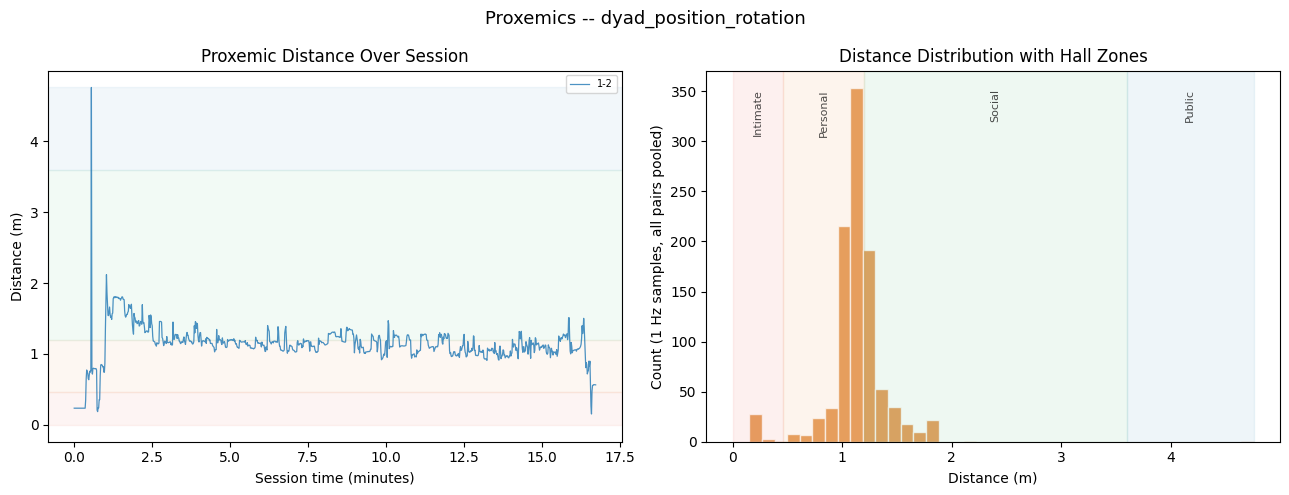

In [10]:
zone_bands = [(0, 0.46, '#e74c3c', 'Intimate'), (0.46, 1.2, '#e67e22', 'Personal'),
              (1.2, 3.6, '#27ae60', 'Social'), (3.6, max(proxemics['distance_m'].max(), 4.0), '#2980b9', 'Public')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for lo, hi, color, label in zone_bands:
    ax.axhspan(lo, hi, color=color, alpha=0.06)
for i, (pa, pb) in enumerate(all_pairs(participants)):
    sub = proxemics[(proxemics.participant_a == pa) & (proxemics.participant_b == pb)]
    ax.plot(sub['session_time_s'] / 60.0, sub['distance_m'], linewidth=0.9,
            color=plt.get_cmap('tab10')(i % 10), alpha=0.8, label=f'{pa}-{pb}')
ax.set_xlabel('Session time (minutes)'); ax.set_ylabel('Distance (m)')
ax.set_title('Proxemic Distance Over Session')
if len(all_pairs(participants)) <= 8:
    ax.legend(fontsize=7, ncol=2)

ax2 = axes[1]
ax2.hist(proxemics['distance_m'].dropna(), bins=40, color=ORANGE, alpha=0.8, edgecolor='white')
for lo, hi, color, label in zone_bands:
    ax2.axvspan(lo, hi, color=color, alpha=0.08)
    ax2.text((lo + min(hi, proxemics['distance_m'].max())) / 2, ax2.get_ylim()[1] * 0.95, label,
              ha='center', va='top', fontsize=8, rotation=90, alpha=0.7)
ax2.set_xlabel('Distance (m)'); ax2.set_ylabel('Count (1 Hz samples, all pairs pooled)')
ax2.set_title('Distance Distribution with Hall Zones')

plt.suptitle(f'Proxemics -- {SELECTED}', fontsize=13)
plt.tight_layout()
plt.savefig(f'proxemics_{SELECTED}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary -- selected dataset

In [11]:
print(f"=== Summary: {SELECTED} ({df['source_format'].iloc[0]}, {len(participants)} participants) ===")
print(f"Temporal synchrony:  mean={temporal_sync['synchrony'].mean():.3f}  (0.5 = chance)")
print(f"Social synchrony:    mean r={social_sync['pearson_r'].mean():.3f}")
if len(hand_tracked) >= 2:
    print(f"Hand synchrony:      mean={hand_sync['synchrony'].mean():.3f}  (0.5 = chance)")
else:
    print("Hand synchrony:      n/a (no hand tracking in this format/session)")
print(f"Proxemics:           mean distance={proxemics['distance_m'].mean():.3f} m  "
      + '  '.join(f'{k}={v:.1f}%' for k, v in overall_zb.items()))

=== Summary: dyad_position_rotation (position_rotation_csv, 2 participants) ===
Temporal synchrony:  mean=0.523  (0.5 = chance)
Social synchrony:    mean r=0.042
Hand synchrony:      mean=0.513  (0.5 = chance)
Proxemics:           mean distance=1.137 m  intimate=3.1%  personal=66.6%  social=30.2%  public=0.1%


## 9. Run the same pipeline across every example dataset

The point of the unified loader/analysis layer: this loop runs the *identical*
code path against all four format families and produces one comparison
table, with no per-format branching.

In [12]:
def run_pipeline(name, spec):
    d = load_session(**spec, session_id=name)
    ppl = sorted(d['participant_id'].unique())
    hz = round(estimate_native_hz(d))
    res = resample_session(d, rate_hz=hz)
    res_1hz = resample_session(d, rate_hz=PROXEMICS_HZ)
    hands = [p for p in ppl if has_hand_data(res[p])]

    ts = temporal_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    ss = social_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    hs = hand_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S) if len(hands) >= 2 else None
    px = compute_proxemics(res_1hz)

    return {
        'dataset': name,
        'format': d['source_format'].iloc[0],
        'n_participants': len(ppl),
        'n_pairs': len(all_pairs(ppl)),
        'duration_s': round(d['t_s'].max() - d['t_s'].min(), 1),
        'native_hz': hz,
        'temporal_sync_mean': round(ts['synchrony'].mean(), 3) if len(ts) else np.nan,
        'social_sync_mean_r': round(ss['pearson_r'].mean(), 3) if len(ss) else np.nan,
        'hand_sync_mean': round(hs['synchrony'].mean(), 3) if hs is not None and len(hs) else np.nan,
        'hand_tracking': bool(hands),
        'proxemics_mean_m': round(px['distance_m'].mean(), 3) if len(px) else np.nan,
    }


comparison = pd.DataFrame([run_pipeline(name, spec) for name, spec in DATASETS.items()])
comparison

,dataset,format,n_participants,n_pairs,duration_s,native_hz,temporal_sync_mean,social_sync_mean_r,hand_sync_mean,hand_tracking,proxemics_mean_m
0,dyad_position_rotation,position_rotation_csv,2,1,1003.8,29,0.523,0.042,0.513,True,1.137
1,quest_7person,quest_csv,7,21,2455.5,30,0.501,0.002,NaN,False,4.012
2,fashion_pkl,pkl_long,2,1,1053.5,10,0.579,0.178,NaN,False,2.198
3,conflab_pkl,pkl_long,3,3,665.0,30,0.508,0.024,NaN,False,1.790
